In [1]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Sequence, Callable
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

In [2]:
# ============================================================
# Configuration:
#   -   Cut period to remove initialization bias
#   -   Remove failed operations from analysis
# ============================================================

# Cut period in seconds - operations in the first N seconds will be excluded
CUT_PERIOD_SECONDS = 10.0

def apply_cut_period(df: pd.DataFrame, cut_seconds: float = CUT_PERIOD_SECONDS) -> pd.DataFrame:
    """
    Filter out operations that started within the first cut_seconds of the run.
    This removes initialization bias from the analysis.
    """
    if len(df) == 0 or cut_seconds <= 0:
        return df
    
    t0 = df["ts_start"].min()
    cutoff_time = t0 + pd.Timedelta(seconds=cut_seconds)
    
    mask = df["ts_start"] >= cutoff_time
    return df[mask].copy()

def remove_failed_operations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove operations that failed (status != "success") from the analysis.
    This focuses the analysis on successful operations only.
    """
    if len(df) == 0:
        return df
    
    df = df[df["success"] == True].copy()

    return df


In [3]:
# ============================================================
# Import a dataframe from a CSV file and preprocess it for analysis.
# ============================================================

def load_summary(file_path: str) -> pd.DataFrame:
    # Load the data from the CSV file
    df = pd.read_csv(file_path)

    # Basic validation
    required = {"ts_start", "ts_end", "success", "latency_ms"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts_start and ts_end columns to datetime format
    df['ts_start'] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    df['ts_end'] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")

    return df

def load_events(file_path: str) -> pd.DataFrame:
    # Load the data from the JSONL file
    df = pd.read_json(file_path, lines=True)

    # Basic validation
    required = {"phase", "nodeId", "reqId"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts column to datetime format
    df['ts'] = pd.to_datetime(df["ts"], utc=True, errors="coerce")

    # Change the nodeId from "15" to "node_15"
    df['nodeId'] = df['nodeId'].apply(lambda x: f"node_{x}" if isinstance(x, int) else x)

    return df

In [4]:
# ============================================================
# Given summary and events return summary with reason of failure for failed operations.
# ============================================================

DEC_PREFIX = "DEC_"

def classify_from_phase(phase: str, op: str) -> Optional[str]:
    """
    Map DEC event phase to failure cause.
    Returns one of: TIMEOUT, UNAVAILABLE, SUCCESS, None
    """
    if not phase:
        return None
    p = str(phase).strip().upper()

    # We only care about DEC events
    if not p.startswith(DEC_PREFIX):
        return None

    # Examples: DEC_GET_TIMEOUT, DEC_UPDATE_FAIL, DEC_GET_SUCCESS ...
    if op == "GET":
        if p == "DEC_GET_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_GET_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_GET_SUCCESS":
            return "SUCCESS"
    elif op == "UPDATE":
        if p == "DEC_UPDATE_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_UPDATE_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_UPDATE_SUCCESS":
            return "SUCCESS"

    # If you ever add other DEC_* phases, you can extend here
    return None

def enrich_summary_with_failure_reasons(summary: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich summary with failure reasons from events.
    Events use: nodeId (converted to "node_XX"), reqId
    Summary uses: node_id, req_id, op
    """
    # Filter events to only include DEC_ events
    dec_events = events[events["phase"].str.startswith(DEC_PREFIX, na=False)].copy()
    
    # Create a mapping of (nodeId, reqId) -> op from summary
    # Summary columns: node_id, req_id, op
    op_map = summary.set_index(["node_id", "req_id"])["op"].to_dict()
    
    # Classify each event using the phase and corresponding op
    def get_reason(row):
        # Events already have nodeId converted to "node_XX" format by load_events
        op = op_map.get((row["nodeId"], row["reqId"]))
        if op:
            return classify_from_phase(row["phase"], op)
        return None
    
    dec_events["reason"] = dec_events.apply(get_reason, axis=1)
    
    # Create a mapping of (nodeId, reqId) to reason (only keep non-None reasons)
    reason_map = dec_events[dec_events["reason"].notna()].set_index(["nodeId", "reqId"])["reason"].to_dict()
    
    # Create a new column in the summary for the failure reason
    # If not found in DEC_ events (i.e., INT_ events), assign "REJECTED"
    summary["failure_reason"] = summary.apply(
        lambda row: reason_map.get((row["node_id"], row["req_id"]), "REJECTED") if not row["success"] else None,
        axis=1
    )
    
    return summary


In [5]:

# ============================================================
# 2) Run-level (per-run) estimators
#    Each returns ONE number per run
# ============================================================

def run_mean_latency_ms(df: pd.DataFrame) -> float:
    """Mean latency in ms for this run."""
    return float(df["latency_ms"].astype(float).mean())


def run_quantile_latency_ms(df: pd.DataFrame, q: float) -> float:
    """Latency quantile (e.g. q=0.5 for median, 0.9, 0.99) for this run."""
    return float(df["latency_ms"].astype(float).quantile(q))


def run_throughput_ops_per_s(df: pd.DataFrame) -> float:
    """
    Throughput = completed ops / elapsed seconds in the run window.
    Uses ts_start min and ts_end max.
    """

    t0 = df["ts_start"].min()
    t1 = df["ts_end"].max()
    elapsed_s = (t1 - t0).total_seconds()

    if elapsed_s <= 0:
        return float("nan")

    return float(len(df) / elapsed_s)

def run_failure_rate(df: pd.DataFrame) -> float:
    """Failure rate = (# failed ops) / (# total ops) in this run."""
    total = len(df)
    if total == 0:
        return float("nan")
    fails = int((df["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_update(df: pd.DataFrame) -> float:
    """Failure rate for update operations only."""
    updates = df[df["op"] == "UPDATE"]
    total = len(updates)
    if total == 0:
        return float("nan")
    fails = int((updates["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_read(df: pd.DataFrame) -> float:
    """Failure rate for read operations only."""
    reads = df[df["op"] == "GET"]
    total = len(reads)
    if total == 0:
        return float("nan")
    fails = int((reads["success"] == False).sum())
    return float(fails / total)

def run_request_per_node(df: pd.DataFrame) -> np.array:
    """Number of requests per node"""
    return df.groupby("node_id")["op"].count().values


def run_request_per_key(df: pd.DataFrame, keyspace: int = 50) -> np.ndarray:
    
    # discard non-data operations
    df_valid = df[df["key"] != -1]

    # Check I do not have outliers
    if not df_valid["key"].between(1, keyspace).all():
        raise ValueError("Found keys outside expected range 1..50")

    # count per key
    counts = df_valid.groupby("key").size()

    # align to full keyspace [1..keyspace]
    return (
        counts
        .reindex(range(1, keyspace + 1), fill_value=0)
        .to_numpy(dtype=np.int64)
    )

def run_failure_rate_per_reason(df: pd.DataFrame) -> Dict[str, float]:
    """
    Failure rate broken down by failure reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    Returns the percentage of total operations that failed with each reason.
    """
    total_ops = len(df)
    if total_ops == 0:
        return {}
    
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    
    # Convert to rates (percentage of total operations)
    rates = {}
    for reason, count in failure_counts.items():
        rates[reason] = float(count / total_ops)
    
    rates["SUCCESS"] = float((df["success"] == True).sum() / total_ops)
    
    return rates

def run_failure_count_per_reason(df: pd.DataFrame) -> Dict[str, int]:
    """
    Count of failures by reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    """
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    failure_counts["SUCCESS"] = (df["success"] == True).sum()
    return failure_counts.to_dict()


In [6]:
# ============================================================
# 3) Confidence intervals across runs
# ============================================================

def t_critical_95(df: int) -> float:
    """
    95% two-sided t critical values for small df (1..30).
    Enough for b=10/20/30.
    If df is larger, we approximate with 1.96.
    """
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042
    }
    return table.get(df, 1.96)

def ci_mean_t(values: Sequence[float], confidence: float = 0.95) -> Tuple[float, float, float]:
    """
    Student-t CI for the mean of run-level values.
    Returns (mean, lo, hi).
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n < 2:
        return (float("nan"), float("nan"), float("nan"))

    mean = sum(xs) / n
    # sample standard deviation (unbiased)
    var = sum((x - mean) ** 2 for x in xs) / (n - 1)
    s = math.sqrt(var)
    se = s / math.sqrt(n)

    # We keep it simple: assume 95% by default
    if abs(confidence - 0.95) > 1e-9:
        raise ValueError("This simple helper supports only 95% CI. Extend if needed.")
    tcrit = t_critical_95(n - 1)

    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return (mean, lo, hi)

def ci_per_key(runs: Sequence[Sequence[float]], confidence: float = 0.95):
    """
    runs: R x K matrix (R runs, K keys)
    returns: list of (mean, lo, hi) of length K
    """
    if not runs:
        return []

    R = len(runs)
    K = len(runs[0])

    # Optional sanity check
    for r in runs:
        if len(r) != K:
            raise ValueError("All runs must have same number of keys")

    # Transpose: get values per key across runs
    results = []
    for k in range(K):
        values_for_key_k = [runs[r][k] for r in range(R)]
        results.append(ci_mean_t(values_for_key_k, confidence))

    return results


def bootstrap_ci_stat(
    values: Sequence[float],
    stat_fn: Callable[[List[float]], float],
    confidence: float = 0.95,
    n_boot: int = 5000,
    seed: int = 0,
) -> Tuple[float, float, float]:
    """
    Bootstrap percentile CI for a statistic over run-level values.
    Returns (point_estimate, lo, hi).

    IMPORTANT: values here should be run-level statistics (e.g., 10 medians),
    not per-operation samples.
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n == 0:
        return (float("nan"), float("nan"), float("nan"))

    rng = random.Random(seed)

    point = stat_fn(xs)

    boot_stats = []
    for _ in range(n_boot):
        sample = [xs[rng.randrange(n)] for _ in range(n)]
        boot_stats.append(stat_fn(sample))

    boot_stats.sort()

    alpha = 1.0 - confidence
    lo_idx = int(math.floor((alpha / 2) * n_boot))
    hi_idx = int(math.ceil((1 - alpha / 2) * n_boot)) - 1
    lo = boot_stats[max(0, min(lo_idx, n_boot - 1))]
    hi = boot_stats[max(0, min(hi_idx, n_boot - 1))]

    return (point, lo, hi)

def median_stat(xs: List[float]) -> float:
    """Median of a list (no numpy)."""
    ys = sorted(xs)
    n = len(ys)
    mid = n // 2
    if n % 2 == 1:
        return float(ys[mid])
    return float((ys[mid - 1] + ys[mid]) / 2)


def quantile_stat(q: float) -> Callable[[List[float]], float]:
    """
    Return a stat function that computes a quantile of a list via
    simple linear interpolation between sorted points.
    """
    def _q(xs: List[float]) -> float:
        ys = sorted(xs)
        n = len(ys)
        if n == 1:
            return float(ys[0])
        # position in [0, n-1]
        pos = q * (n - 1)
        lo = int(math.floor(pos))
        hi = int(math.ceil(pos))
        if lo == hi:
            return float(ys[lo])
        w = pos - lo
        return float(ys[lo] * (1 - w) + ys[hi] * w)
    return _q

In [7]:
def plot_cumulative_averages(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput over time for all runs in a folder.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    ax_lat, ax_thr = axes
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        # Sort by end time
        df = df.sort_values('ts_end').reset_index(drop=True)
        
        # Cumulative average latency
        cumsum_latency = df['latency_ms'].cumsum()
        cum_avg_latency = cumsum_latency / (np.arange(len(df)) + 1)
        
        # Cumulative average throughput (ops/s from start to each point)
        t0 = df['ts_start'].min()
        elapsed_seconds = (df['ts_end'] - t0).dt.total_seconds()
        cum_avg_throughput = (np.arange(len(df)) + 1) / elapsed_seconds
        
        # Plot
        label = folder.name
        ax_lat.plot(elapsed_seconds, cum_avg_latency, label=label, alpha=0.7)
        ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=label, alpha=0.7)
    
    # Configure latency plot
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency over Time - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Configure throughput plot
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput over Time - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
SUMMARY_NAME = "summary.csv"

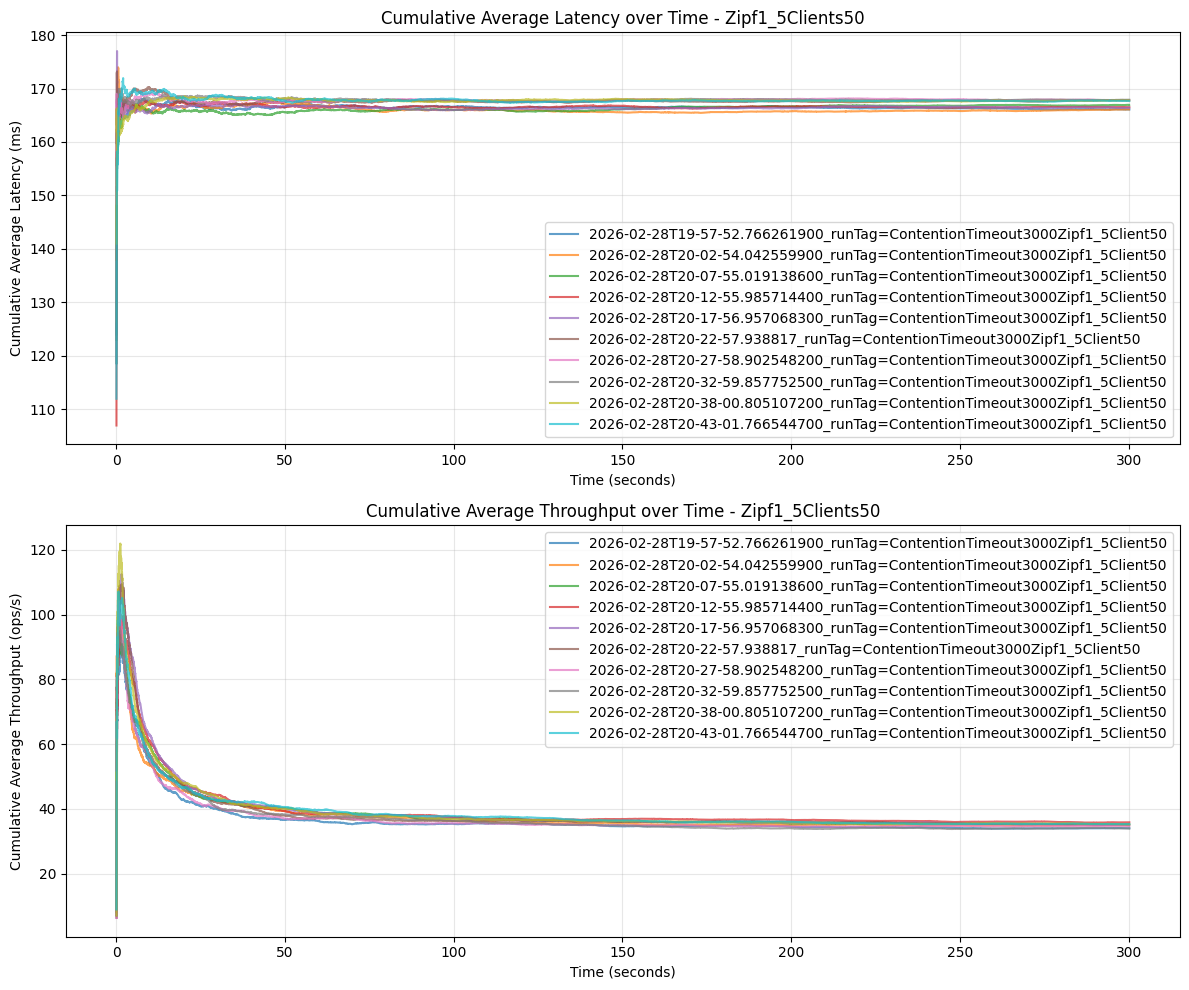

In [8]:
DATA_DIR = Path("Zipf1_5Clients50")


plot_cumulative_averages(DATA_DIR, apply_cut=False)

In [9]:
def plot_cumulative_averages_across_runs(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput across all runs in a configuration.
    This aggregates all operations from all runs and shows the cumulative average.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    # Collect all operations from all runs
    all_operations = []
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        all_operations.append(df)
    
    if len(all_operations) == 0:
        print(f"No data found in {data_dir}")
        return
    
    # Combine all runs
    combined_df = pd.concat(all_operations, ignore_index=True)
    
    # Sort by end time
    combined_df = combined_df.sort_values('ts_end').reset_index(drop=True)
    
    # Cumulative average latency
    cumsum_latency = combined_df['latency_ms'].cumsum()
    cum_avg_latency = cumsum_latency / (np.arange(len(combined_df)) + 1)
    
    # Cumulative average throughput (ops/s from start to each point)
    t0 = combined_df['ts_start'].min()
    elapsed_seconds = (combined_df['ts_end'] - t0).dt.total_seconds()
    cum_avg_throughput = (np.arange(len(combined_df)) + 1) / elapsed_seconds
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=(6, 5))
    ax_lat, ax_thr = axes
    
    # Plot latency
    ax_lat.plot(elapsed_seconds, cum_avg_latency, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency Across All Runs - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Plot throughput
    ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput Across All Runs - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nConfiguration: {data_dir.name}")
    print(f"  Total runs: {len(all_operations)}")
    print(f"  Total successful operations: {len(combined_df)}")
    print(f"  Final cumulative average latency: {cum_avg_latency.iloc[-1]:.2f} ms")
    print(f"  Final cumulative average throughput: {cum_avg_throughput.iloc[-1]:.2f} ops/s")

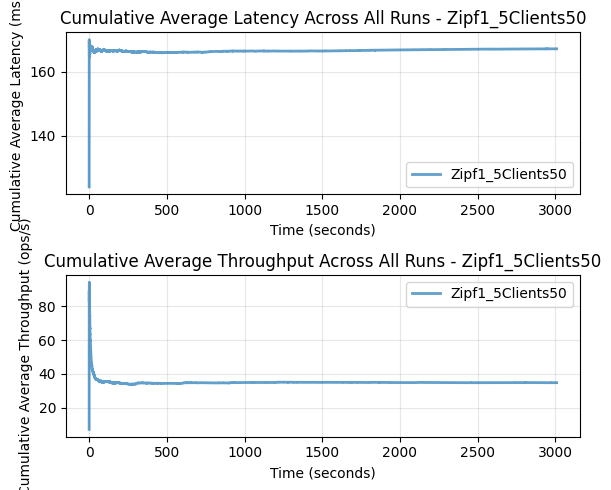


Configuration: Zipf1_5Clients50
  Total runs: 10
  Total successful operations: 104820
  Final cumulative average latency: 167.09 ms
  Final cumulative average throughput: nan ops/s


In [10]:
plot_cumulative_averages_across_runs(Path("Zipf1_5Clients50"), apply_cut=False)

Processing Zipf0Clients20...


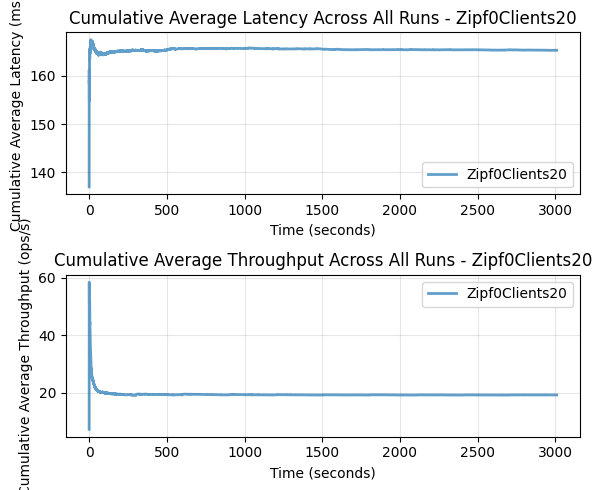


Configuration: Zipf0Clients20
  Total runs: 10
  Total successful operations: 57909
  Final cumulative average latency: 165.28 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf0Clients5...


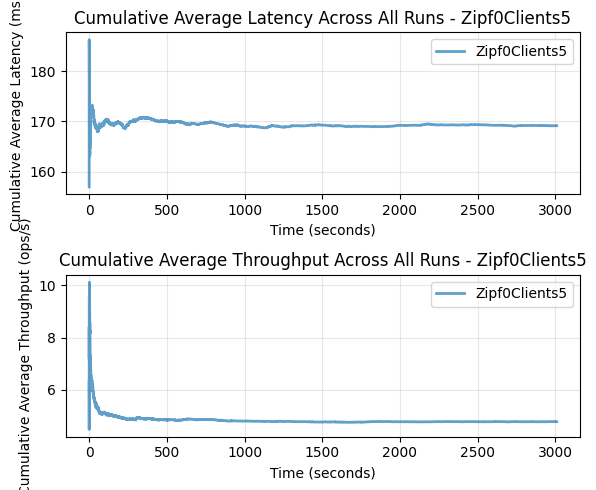


Configuration: Zipf0Clients5
  Total runs: 10
  Total successful operations: 14350
  Final cumulative average latency: 169.16 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf0Clients50...


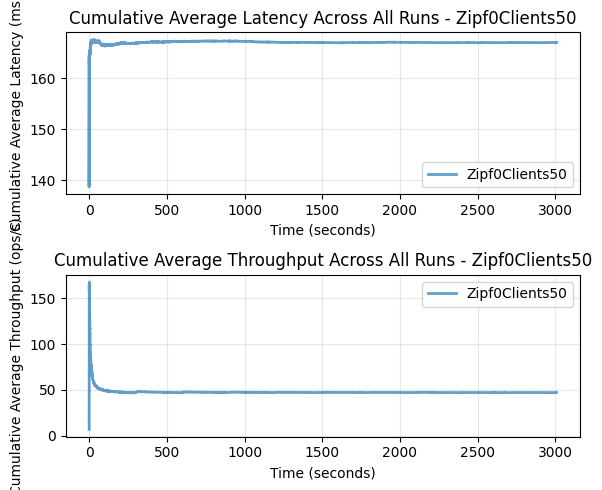


Configuration: Zipf0Clients50
  Total runs: 10
  Total successful operations: 141888
  Final cumulative average latency: 167.06 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients100...


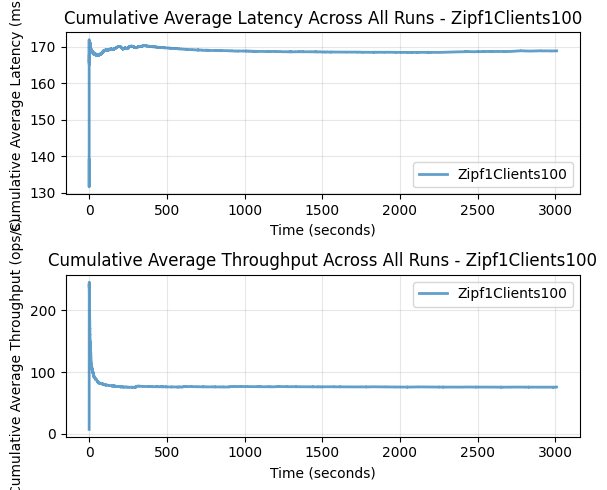


Configuration: Zipf1Clients100
  Total runs: 10
  Total successful operations: 227624
  Final cumulative average latency: 168.87 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients1000...


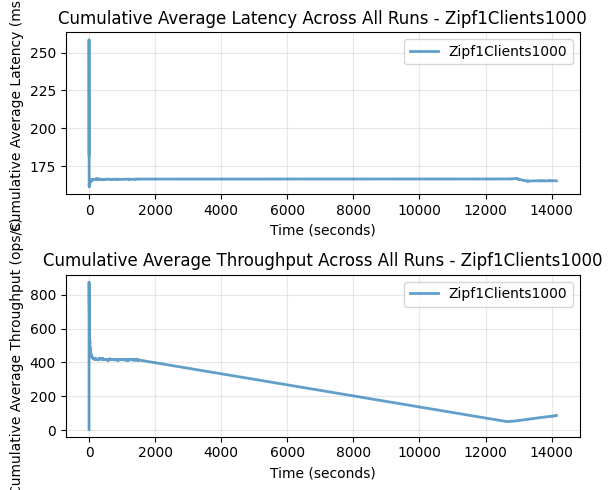


Configuration: Zipf1Clients1000
  Total runs: 10
  Total successful operations: 1205644
  Final cumulative average latency: 165.47 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients20...


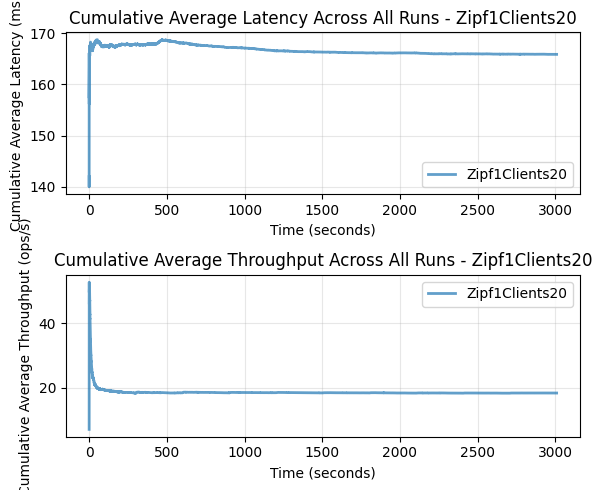


Configuration: Zipf1Clients20
  Total runs: 10
  Total successful operations: 55163
  Final cumulative average latency: 165.87 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients5...


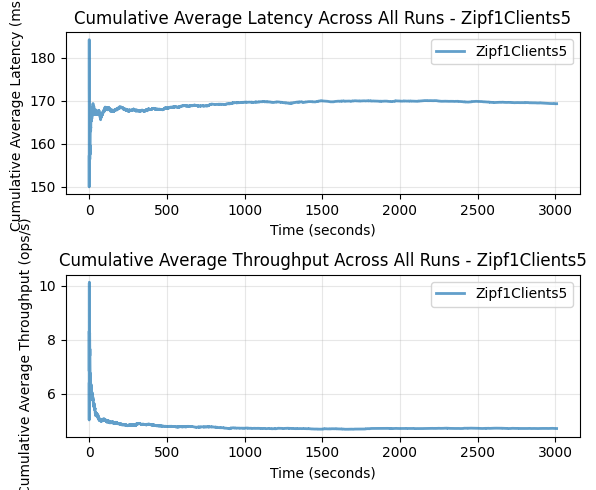


Configuration: Zipf1Clients5
  Total runs: 10
  Total successful operations: 14220
  Final cumulative average latency: 169.32 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients50...


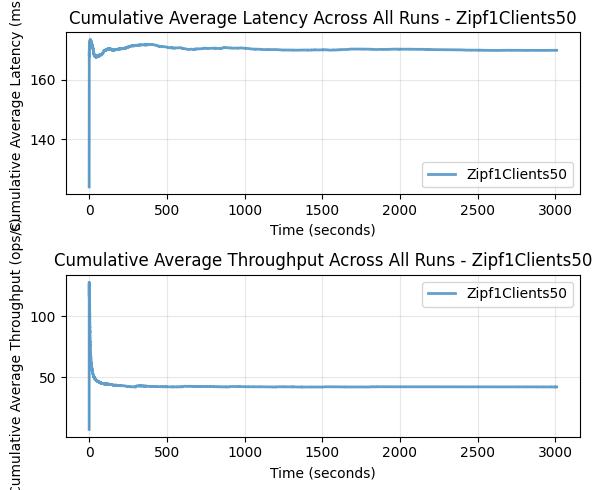


Configuration: Zipf1Clients50
  Total runs: 10
  Total successful operations: 126211
  Final cumulative average latency: 170.00 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1Clients500...


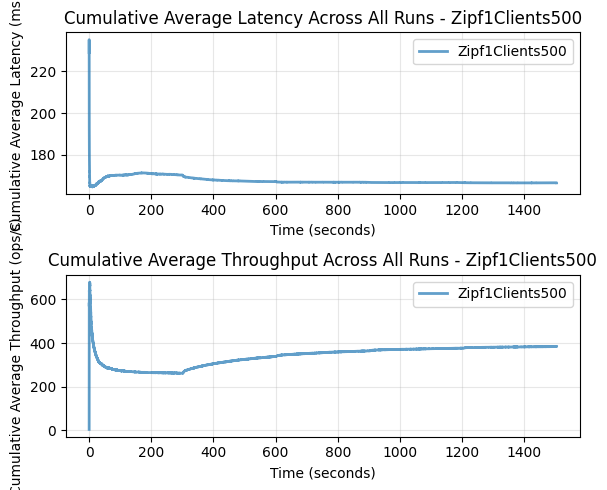


Configuration: Zipf1Clients500
  Total runs: 5
  Total successful operations: 578018
  Final cumulative average latency: 166.54 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1_5Clients20...


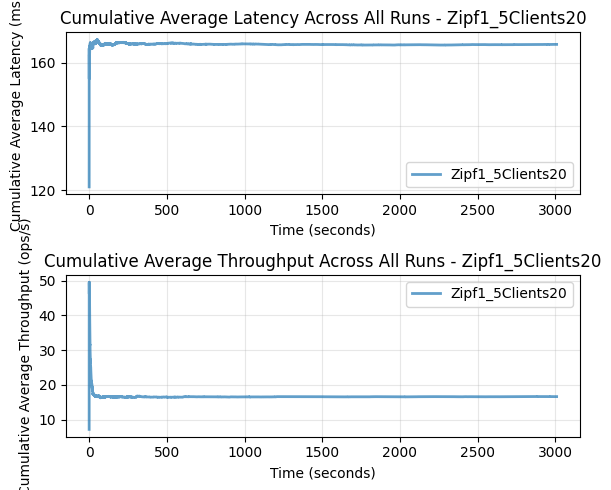


Configuration: Zipf1_5Clients20
  Total runs: 10
  Total successful operations: 50053
  Final cumulative average latency: 165.83 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1_5Clients5...


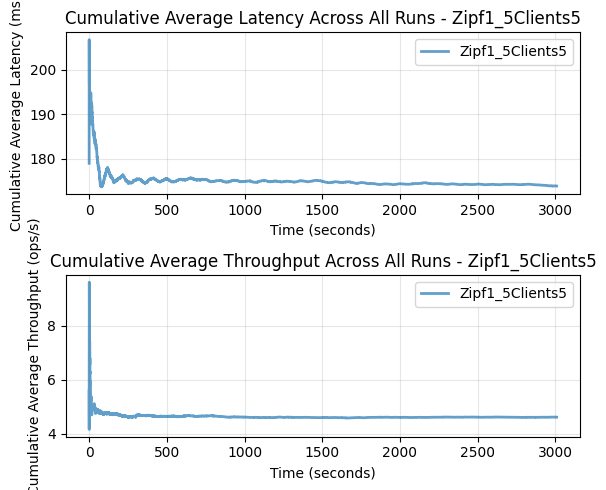


Configuration: Zipf1_5Clients5
  Total runs: 10
  Total successful operations: 13875
  Final cumulative average latency: 173.90 ms
  Final cumulative average throughput: nan ops/s
Processing Zipf1_5Clients50...


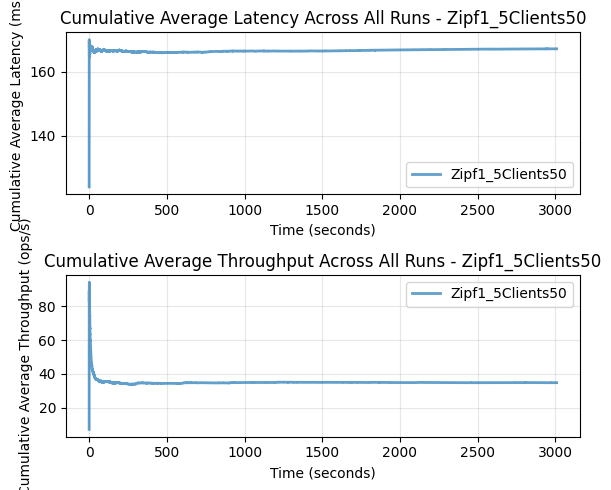


Configuration: Zipf1_5Clients50
  Total runs: 10
  Total successful operations: 104820
  Final cumulative average latency: 167.09 ms
  Final cumulative average throughput: nan ops/s


In [11]:
BASE_DIR = Path("./")

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        plot_cumulative_averages_across_runs(Path(folder), apply_cut=False)

In [12]:
# You can adjust CUT_PERIOD_SECONDS at the top to change the cut period
# Current setting: first 10 seconds of each run are excluded from analysis
DATA_DIR = Path("Zipf1_5Clients50")
SUMMARY_NAME = "summary.csv"

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        df = load_summary(folder / SUMMARY_NAME)
        df = apply_cut_period(df)
        filan_df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))
        print(f"Run: {folder.name}")
        print(f"  Failure rate by reason: {run_failure_rate_per_reason(filan_df)}")
        print(f"  Failure count by reason: {run_failure_count_per_reason(filan_df)}")

Run: 2026-02-28T19-57-52.766261900_runTag=ContentionTimeout3000Zipf1_5Client50
  Failure rate by reason: {'UNAVAILABLE': 0.14954572098475968, 'REJECTED': 0.13694314185228604, 'TIMEOUT': 0.0051289566236811255, 'SUCCESS': 0.7083821805392732}
  Failure count by reason: {'UNAVAILABLE': 2041, 'REJECTED': 1869, 'TIMEOUT': 70, 'SUCCESS': 9668}
Run: 2026-02-28T20-02-54.042559900_runTag=ContentionTimeout3000Zipf1_5Client50
  Failure rate by reason: {'UNAVAILABLE': 0.1451473136915078, 'REJECTED': 0.13258232235701906, 'TIMEOUT': 0.004332755632582322, 'SUCCESS': 0.7179376083188909}
  Failure count by reason: {'UNAVAILABLE': 2010, 'REJECTED': 1836, 'TIMEOUT': 60, 'SUCCESS': 9942}
Run: 2026-02-28T20-07-55.019138600_runTag=ContentionTimeout3000Zipf1_5Client50
  Failure rate by reason: {'UNAVAILABLE': 0.13896952104499274, 'REJECTED': 0.13497822931785197, 'TIMEOUT': 0.0044992743105950654, 'SUCCESS': 0.7215529753265603}
  Failure count by reason: {'UNAVAILABLE': 1915, 'REJECTED': 1860, 'TIMEOUT': 62, 'S

In [14]:
# ============================================================
# Compute statistics across runs and confidence intervals
# ============================================================
SUMMARY_NAME = "summary.csv"

def compute_stat_across_runs(
    data_dir: Path,
) -> Dict:
    """
    Compute statistics across runs and confidence intervals.
    Returns a dictionary of statistic name -> (point_estimate, ci_lo, ci_hi).
    """
    p50_r = []
    p50_w = []
    p95_r = []
    p95_w = []
    p99_r = []
    p99_w = []

    throughput = []
    throughput_r = []
    throughput_w = []

    success_rate = []
    timeout_rate = []
    busy_rate = []
    per_key_operations = []

    for folder in data_dir.iterdir():
        if folder.is_dir():
            df = load_summary(folder / SUMMARY_NAME)
            df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))

            df = apply_cut_period(df)

            df_success = remove_failed_operations(df)

            # Now I compute run-level stats
            df_r = df_success[df_success["op"] == "GET"]
            df_w = df_success[df_success["op"] == "UPDATE"]

            p50_r.append(run_quantile_latency_ms(df_r, 0.5))
            p50_w.append(run_quantile_latency_ms(df_w, 0.5))
            p95_r.append(run_quantile_latency_ms(df_r, 0.95))
            p95_w.append(run_quantile_latency_ms(df_w, 0.95))
            p99_r.append(run_quantile_latency_ms(df_r, 0.99))
            p99_w.append(run_quantile_latency_ms(df_w, 0.99))

            throughput.append(run_throughput_ops_per_s(df_success))
            throughput_r.append(run_throughput_ops_per_s(df_r))
            throughput_w.append(run_throughput_ops_per_s(df_w))

            rates = run_failure_rate_per_reason(df)
            success_rate.append(rates.get("SUCCESS", 0))
            timeout_rate.append(rates.get("TIMEOUT", 0))
            busy_rate.append(rates.get("UNAVAILABLE", 0) + rates.get("REJECTED", 0))
            per_key_operations.append(run_request_per_key(df))  # average ops per key
    
    # Compute mean and CI for each metric
    summary_stats = {
        # Read latency percentiles
        "p50_read_ms": {
            "median": bootstrap_ci_stat(p50_r, median_stat)
        },
        "p95_read_ms": {
            "median": bootstrap_ci_stat(p95_r, median_stat)
        },
        "p99_read_ms": {
            "median": bootstrap_ci_stat(p99_r, median_stat)
        },
        
        # Write latency percentiles
        "p50_write_ms": {
            "median": bootstrap_ci_stat(p50_w, median_stat)
        },
        "p95_write_ms": {
            "median": bootstrap_ci_stat(p95_w, median_stat)
        },
        "p99_write_ms": {
            "median": bootstrap_ci_stat(p99_w, median_stat)
        },
        
        # Throughput metrics
        "throughput_ops_per_s": {
            "mean": ci_mean_t(throughput),
        },
        "throughput_read_ops_per_s": {
            "mean": ci_mean_t(throughput_r),
        },
        "throughput_write_ops_per_s": {
            "mean": ci_mean_t(throughput_w),
        },
        
        # Success and failure rates
        "success_rate": {
            "mean": ci_mean_t(success_rate),
        },
        "timeout_rate": {
            "mean": ci_mean_t(timeout_rate),
        },
        "busy_rate": {
            "mean": ci_mean_t(busy_rate),
        },

        # Per key operations
        "per_key_operations": {
            "array_means": ci_per_key(per_key_operations),
        }
    }

    return summary_stats

In [19]:
BASE_DIR = Path("./")

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        stats = compute_stat_across_runs(Path(folder))
        final_stats[folder.name] = stats

Processing Zipf0Clients20...
Processing Zipf0Clients5...
Processing Zipf0Clients50...
Processing Zipf1Clients100...
Processing Zipf1Clients1000...
Processing Zipf1Clients20...
Processing Zipf1Clients5...
Processing Zipf1Clients50...
Processing Zipf1Clients500...
Processing Zipf1_5Clients20...
Processing Zipf1_5Clients5...
Processing Zipf1_5Clients50...


In [20]:
# Create a comparative DataFrame across all configurations
comparison_rows = []

for config_name, stats in final_stats.items():
    row = {"configuration": config_name}
    
    for metric_name, estimators in stats.items():
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            row[f"{metric_name}_mean"] = mean_point
            row[f"{metric_name}_mean_ci_lo"] = mean_lo
            row[f"{metric_name}_mean_ci_hi"] = mean_hi
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            row[f"{metric_name}_median"] = median_point
            row[f"{metric_name}_median_ci_lo"] = median_lo
            row[f"{metric_name}_median_ci_hi"] = median_hi
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 100)
print("COMPARATIVE STATISTICS TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False))

# You can save it to CSV:
# comparison_df.to_csv("quorum_comparison.csv", index=False)



COMPARATIVE STATISTICS TABLE
   configuration  p50_read_ms_median  p50_read_ms_median_ci_lo  p50_read_ms_median_ci_hi  p95_read_ms_median  p95_read_ms_median_ci_lo  p95_read_ms_median_ci_hi  p99_read_ms_median  p99_read_ms_median_ci_lo  p99_read_ms_median_ci_hi  p50_write_ms_median  p50_write_ms_median_ci_lo  p50_write_ms_median_ci_hi  p95_write_ms_median  p95_write_ms_median_ci_lo  p95_write_ms_median_ci_hi  p99_write_ms_median  p99_write_ms_median_ci_lo  p99_write_ms_median_ci_hi  throughput_ops_per_s_mean  throughput_ops_per_s_mean_ci_lo  throughput_ops_per_s_mean_ci_hi  throughput_read_ops_per_s_mean  throughput_read_ops_per_s_mean_ci_lo  throughput_read_ops_per_s_mean_ci_hi  throughput_write_ops_per_s_mean  throughput_write_ops_per_s_mean_ci_lo  throughput_write_ops_per_s_mean_ci_hi  success_rate_mean  success_rate_mean_ci_lo  success_rate_mean_ci_hi  timeout_rate_mean  timeout_rate_mean_ci_lo  timeout_rate_mean_ci_hi  busy_rate_mean  busy_rate_mean_ci_lo  busy_rate_mean_ci_hi
  

In [21]:
# Create a comparative DataFrame across all configurations
comparison_rows = []

for config_name, stats in final_stats.items():
    row = {"configuration": config_name}
    
    for metric_name, estimators in stats.items():
        if metric_name != "throughput_ops_per_s" and metric_name != "busy_rate":
            continue  # skip this complex metric for the summary table
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            row[f"{metric_name}_mean"] = mean_point
            row[f"{metric_name}_mean_ci_lo"] = mean_lo
            row[f"{metric_name}_mean_ci_hi"] = mean_hi
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            row[f"{metric_name}_median"] = median_point
            row[f"{metric_name}_median_ci_lo"] = median_lo
            row[f"{metric_name}_median_ci_hi"] = median_hi
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 100)
print("COMPARATIVE STATISTICS TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False))

# You can save it to CSV:
# comparison_df.to_csv("quorum_comparison.csv", index=False)



COMPARATIVE STATISTICS TABLE
   configuration  throughput_ops_per_s_mean  throughput_ops_per_s_mean_ci_lo  throughput_ops_per_s_mean_ci_hi  busy_rate_mean  busy_rate_mean_ci_lo  busy_rate_mean_ci_hi
  Zipf0Clients20                  18.800390                        18.679549                        18.921230        0.012079              0.010948              0.013210
   Zipf0Clients5                   4.716975                         4.676041                         4.757909        0.003063              0.002210              0.003916
  Zipf0Clients50                  45.778859                        45.611434                        45.946284        0.033090              0.032108              0.034072
 Zipf1Clients100                  73.831570                        73.334443                        74.328697        0.207904              0.204241              0.211568
Zipf1Clients1000                 405.785104                       404.158959                       407.411249        0.5

In [18]:
i = 0
for key, value in final_stats.items():
    print(f"{key}:")
    if (i == 0):
        for metric, estimators in value.items():
            print(f"  {metric}")
    i += 1

Zipf0Clients20:
  p50_read_ms
  p95_read_ms
  p99_read_ms
  p50_write_ms
  p95_write_ms
  p99_write_ms
  throughput_ops_per_s
  throughput_read_ops_per_s
  throughput_write_ops_per_s
  success_rate
  timeout_rate
  busy_rate
  per_key_operations
Zipf0Clients5:
Zipf0Clients50:
Zipf1Clients100:
Zipf1Clients1000:
Zipf1Clients20:
Zipf1Clients5:
Zipf1Clients50:
Zipf1Clients500:
Zipf1_5Clients20:
Zipf1_5Clients5:
Zipf1_5Clients50:


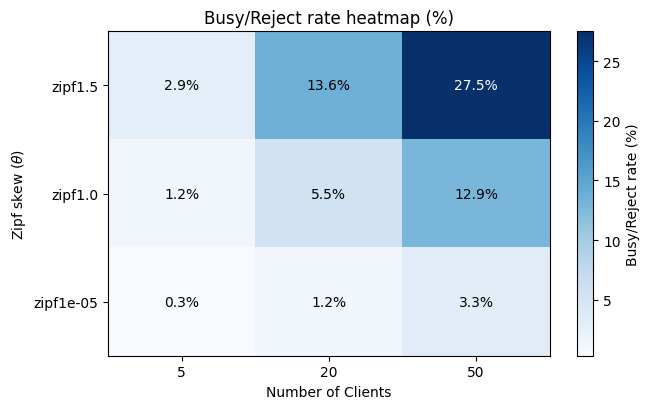

In [35]:
HEAT_DATA = {
    0.00001: {5: final_stats["Zipf0Clients5"]["busy_rate"]["mean"],
              20: final_stats["Zipf0Clients20"]["busy_rate"]["mean"],
              50: final_stats["Zipf0Clients50"]["busy_rate"]["mean"],
              },
    1.0:  {5: final_stats["Zipf1Clients5"]["busy_rate"]["mean"],
           20: final_stats["Zipf1Clients20"]["busy_rate"]["mean"],
           50: final_stats["Zipf1Clients50"]["busy_rate"]["mean"],
           },
    1.5:  {5: final_stats["Zipf1_5Clients5"]["busy_rate"]["mean"],
           20: final_stats["Zipf1_5Clients20"]["busy_rate"]["mean"],
           50: final_stats["Zipf1_5Clients50"]["busy_rate"]["mean"],
           },
}

import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50]
ZIPF_LEVELS = [1.5, 1.0, 0.00001]

PLOT_AS_PERCENT = True   # your rates are fractions, so True -> show as %

def plot_busy_heatmap(heat_data: dict, zipf_levels, client_levels, plot_as_percent=True):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Build matrix (rows=zipf, cols=clients)
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)

    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    im = ax.imshow(Z, aspect="auto", cmap="Blues")  # don't force square cells

    ax.set_xticks(np.arange(len(client_levels)), [f"{c}" for c in client_levels])
    ax.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])

    ax.set_xlabel("Number of Clients")
    ax.set_ylabel("Zipf skew ($\\theta$)")
    ax.set_title("Busy/Reject rate heatmap (%)")

    # Print values inside cells
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                text_color = "white" if v > 25 else "black"
                ax.text(j, i, f"{v:.1f}{unit}", ha="center", va="center", color=text_color)


    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"Busy/Reject rate ({unit})" if unit else "Busy/Reject rate")

    fig.tight_layout()
    plt.savefig("heat_fail.png", dpi=300)
    plt.show()

# Call it
plot_busy_heatmap(HEAT_DATA, ZIPF_LEVELS, CLIENT_LEVELS, plot_as_percent=PLOT_AS_PERCENT)

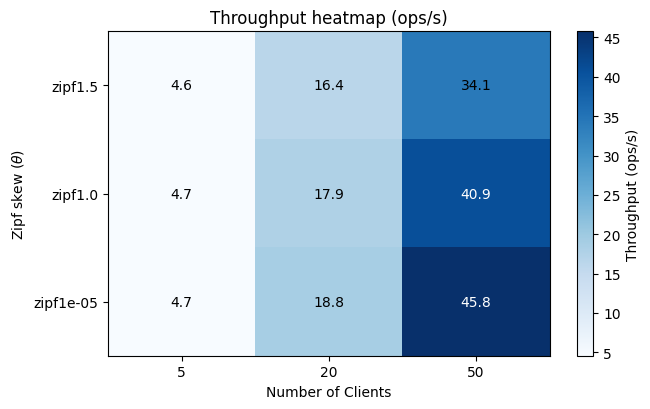

In [34]:
HEAT_DATA = {
    0.00001: {5: final_stats["Zipf0Clients5"]["throughput_ops_per_s"]["mean"],
              20: final_stats["Zipf0Clients20"]["throughput_ops_per_s"]["mean"],
              50: final_stats["Zipf0Clients50"]["throughput_ops_per_s"]["mean"],
              },
    1.0:  {5: final_stats["Zipf1Clients5"]["throughput_ops_per_s"]["mean"],
           20: final_stats["Zipf1Clients20"]["throughput_ops_per_s"]["mean"],
           50: final_stats["Zipf1Clients50"]["throughput_ops_per_s"]["mean"],
           },
    1.5:  {5: final_stats["Zipf1_5Clients5"]["throughput_ops_per_s"]["mean"],
           20: final_stats["Zipf1_5Clients20"]["throughput_ops_per_s"]["mean"],
           50: final_stats["Zipf1_5Clients50"]["throughput_ops_per_s"]["mean"],
           },
}

import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50]
ZIPF_LEVELS = [1.5, 1.0, 0.00001]

PLOT_AS_PERCENT = False

def plot_throughput_heatmap(heat_data: dict, zipf_levels, client_levels, plot_as_percent=False):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Build matrix (rows=zipf, cols=clients)
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)

    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    im = ax.imshow(Z, aspect="auto", cmap="Blues")

    ax.set_xticks(np.arange(len(client_levels)), [f"{c}" for c in client_levels])
    ax.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])

    ax.set_xlabel("Number of Clients")
    ax.set_ylabel("Zipf skew ($\\theta$)")
    ax.set_title("Throughput heatmap (ops/s)")

    # Print values inside cells
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                text_color = "white" if v > 35 else "black"
                ax.text(j, i, f"{v:.1f}{unit}", ha="center", va="center", color=text_color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"Throughput (ops/s)")

    fig.tight_layout()
    fig.savefig("heat_t.png")
    plt.show()

plot_throughput_heatmap(HEAT_DATA, ZIPF_LEVELS, CLIENT_LEVELS, plot_as_percent=PLOT_AS_PERCENT)


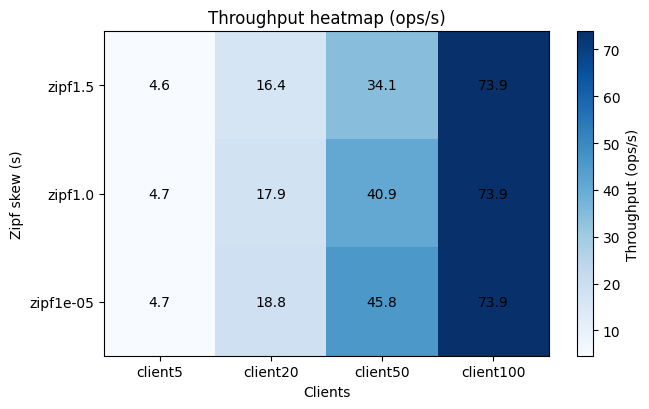

In [30]:
HEAT_DATA = {
    0.00001: {5: final_stats["Zipf0Clients5"]["throughput_ops_per_s"]["mean"],
              20: final_stats["Zipf0Clients20"]["throughput_ops_per_s"]["mean"],
              50: final_stats["Zipf0Clients50"]["throughput_ops_per_s"]["mean"],
              100: summary_stats["throughput_ops_per_s"]["mean"],
              },
    1.0:  {5: final_stats["Zipf1Clients5"]["throughput_ops_per_s"]["mean"],
           20: final_stats["Zipf1Clients20"]["throughput_ops_per_s"]["mean"],
           50: final_stats["Zipf1Clients50"]["throughput_ops_per_s"]["mean"],
              100: summary_stats["throughput_ops_per_s"]["mean"],
           },
    1.5:  {5: final_stats["Zipf1_5Clients5"]["throughput_ops_per_s"]["mean"],
           20: final_stats["Zipf1_5Clients20"]["throughput_ops_per_s"]["mean"],
           50: final_stats["Zipf1_5Clients50"]["throughput_ops_per_s"]["mean"],
           100: summary_stats["throughput_ops_per_s"]["mean"],
           },
}

import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50, 100]
ZIPF_LEVELS = [1.5, 1.0, 0.00001]

PLOT_AS_PERCENT = False

def plot_throughput_heatmap(heat_data: dict, zipf_levels, client_levels, plot_as_percent=False):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Build matrix (rows=zipf, cols=clients)
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)

    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    im = ax.imshow(Z, aspect="auto", cmap="Blues")

    ax.set_xticks(np.arange(len(client_levels)), [f"client{c}" for c in client_levels])
    ax.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])

    ax.set_xlabel("Clients")
    ax.set_ylabel("Zipf skew (s)")
    ax.set_title("Throughput heatmap (ops/s)")

    # Print values inside cells
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}{unit}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"Throughput (ops/s)")

    fig.tight_layout()
    plt.show()

plot_throughput_heatmap(HEAT_DATA, ZIPF_LEVELS, CLIENT_LEVELS, plot_as_percent=PLOT_AS_PERCENT)


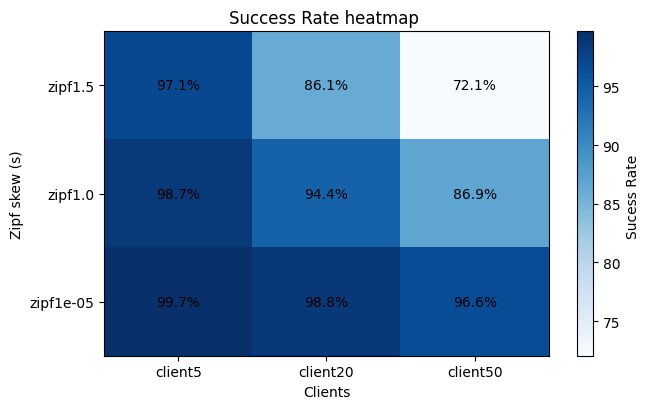

In [91]:
HEAT_DATA = {
    0.00001: {5: final_stats["Zipf0Clients5"]["success_rate"]["mean"],
              20: final_stats["Zipf0Clients20"]["success_rate"]["mean"],
              50: final_stats["Zipf0Clients50"]["success_rate"]["mean"],
              },
    1.0:  {5: final_stats["Zipf1Clients5"]["success_rate"]["mean"],
           20: final_stats["Zipf1Clients20"]["success_rate"]["mean"],
           50: final_stats["Zipf1Clients50"]["success_rate"]["mean"],
           },
    1.5:  {5: final_stats["Zipf1_5Clients5"]["success_rate"]["mean"],
           20: final_stats["Zipf1_5Clients20"]["success_rate"]["mean"],
           50: final_stats["Zipf1_5Clients50"]["success_rate"]["mean"],
           },
}

import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50]
ZIPF_LEVELS = [1.5, 1.0, 0.00001]

PLOT_AS_PERCENT = True

def plot_throughput_heatmap(heat_data: dict, zipf_levels, client_levels, plot_as_percent=False):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Build matrix (rows=zipf, cols=clients)
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)

    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    im = ax.imshow(Z, aspect="auto", cmap="Blues")

    ax.set_xticks(np.arange(len(client_levels)), [f"client{c}" for c in client_levels])
    ax.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])

    ax.set_xlabel("Clients")
    ax.set_ylabel("Zipf skew (s)")
    ax.set_title("Success Rate heatmap ")

    # Print values inside cells
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}{unit}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"Sucess Rate ")

    fig.tight_layout()
    plt.show()

plot_throughput_heatmap(HEAT_DATA, ZIPF_LEVELS, CLIENT_LEVELS, plot_as_percent=PLOT_AS_PERCENT)


In [30]:
np.array(final_stats['Zipf0Clients50']['per_key_operations']['array_means'])

array([[280.9       , 268.30368584, 293.49631416],
       [280.2       , 269.76424775, 290.63575225],
       [279.8       , 265.88956846, 293.71043154],
       [283.9       , 274.98205723, 292.81794277],
       [274.3       , 261.26626431, 287.33373569],
       [279.1       , 271.7706701 , 286.4293299 ],
       [274.        , 265.324084  , 282.675916  ],
       [284.4       , 276.46184446, 292.33815554],
       [276.9       , 271.1929621 , 282.6070379 ],
       [269.5       , 262.5545999 , 276.4454001 ],
       [272.4       , 261.94574174, 282.85425826],
       [276.1       , 266.45321898, 285.74678102],
       [279.8       , 270.52365472, 289.07634528],
       [272.8       , 263.39583343, 282.20416657],
       [274.5       , 262.49149954, 286.50850046],
       [280.2       , 269.04283802, 291.35716198],
       [266.9       , 253.1265435 , 280.6734565 ],
       [276.        , 265.98569911, 286.01430089],
       [279.1       , 263.13922513, 295.06077487],
       [263.        , 253.67963

In [31]:
np.array(final_stats['Zipf0Clients50']['per_key_operations']['array_means']).T[0]

array([280.9, 280.2, 279.8, 283.9, 274.3, 279.1, 274. , 284.4, 276.9,
       269.5, 272.4, 276.1, 279.8, 272.8, 274.5, 280.2, 266.9, 276. ,
       279.1, 263. , 267.9, 282.7, 275.1, 279.2, 277.3, 278.9, 272.5,
       269.3, 272.4, 279.8, 278.7, 274. , 272. , 279.3, 273.7, 277.1,
       265.6, 269.4, 273.1, 266.8, 270.9, 275.8, 267.9, 272.3, 280.9,
       273. , 279.5, 275.4, 267.5, 277.9])

/tmp/ipykernel_7992/3422795199.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


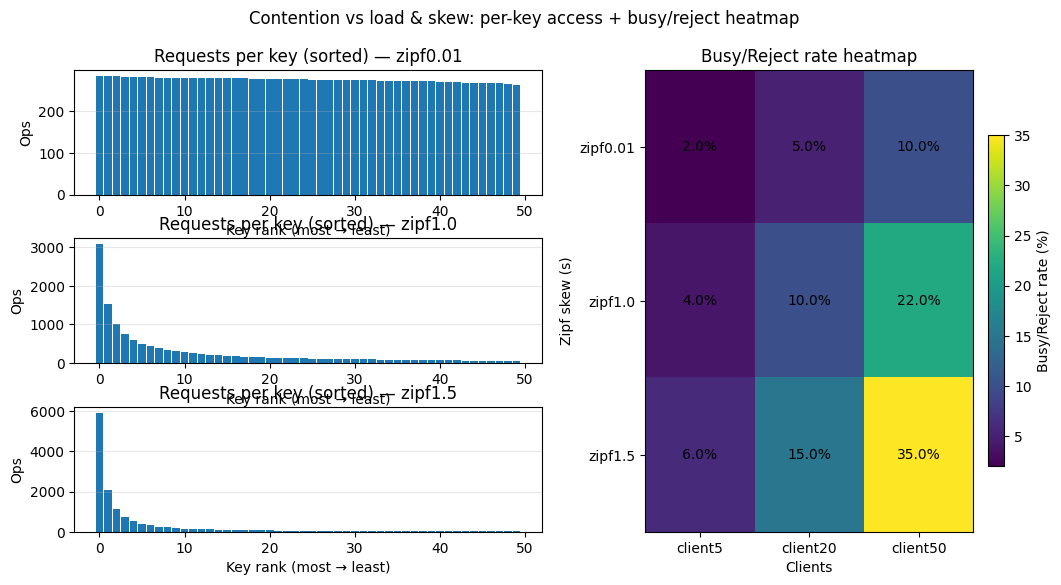

In [32]:
HIST_DATA = {
    0.01: np.array(final_stats['Zipf0Clients50']['per_key_operations']['array_means']).T[0],  # counts per key
    1.0:  np.array(final_stats['Zipf1Clients50']['per_key_operations']['array_means']).T[0],
    1.5:  np.array(final_stats['Zipf1_5Clients50']['per_key_operations']['array_means']).T[0],
}
def plot_heatmap_with_zipf_histograms(
    heat_data: dict,
    hist_data: dict,
    zipf_levels,
    client_levels,
    plot_as_percent=True,
):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Heatmap matrix
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)
    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[1.3, 1.0], wspace=0.25, hspace=0.35)

    # Left: 3 hist panels
    for r, s in enumerate(zipf_levels):
        ax = fig.add_subplot(gs[r, 0])
        counts = np.asarray(hist_data[s], dtype=float)
        counts = np.where(np.isfinite(counts), counts, 0.0)

        # Sort by operations per key (descending)
        counts_sorted = np.sort(counts)[::-1]

        ax.bar(np.arange(len(counts_sorted)), counts_sorted, width=0.9)
        ax.set_title(f"Requests per key (sorted) — zipf{s}")
        ax.set_xlabel("Key rank (most → least)")
        ax.set_ylabel("Ops")
        ax.grid(True, axis="y", alpha=0.3)

    # Right: heatmap spans all rows
    axh = fig.add_subplot(gs[:, 1])
    im = axh.imshow(Z, aspect="auto")

    axh.set_xticks(np.arange(len(client_levels)), [f"client{c}" for c in client_levels])
    axh.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])
    axh.set_xlabel("Clients")
    axh.set_ylabel("Zipf skew (s)")
    axh.set_title("Busy/Reject rate heatmap")

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                axh.text(j, i, f"{v:.1f}{unit}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    cbar.set_label(f"Busy/Reject rate ({unit})" if unit else "Busy/Reject rate")

    fig.suptitle("Contention vs load & skew: per-key access + busy/reject heatmap")
    fig.tight_layout()
    plt.show()

# Call it (requires both HEAT_DATA and HIST_DATA)
plot_heatmap_with_zipf_histograms(
    HEAT_DATA,
    HIST_DATA,
    ZIPF_LEVELS,
    CLIENT_LEVELS,
    plot_as_percent=True
)

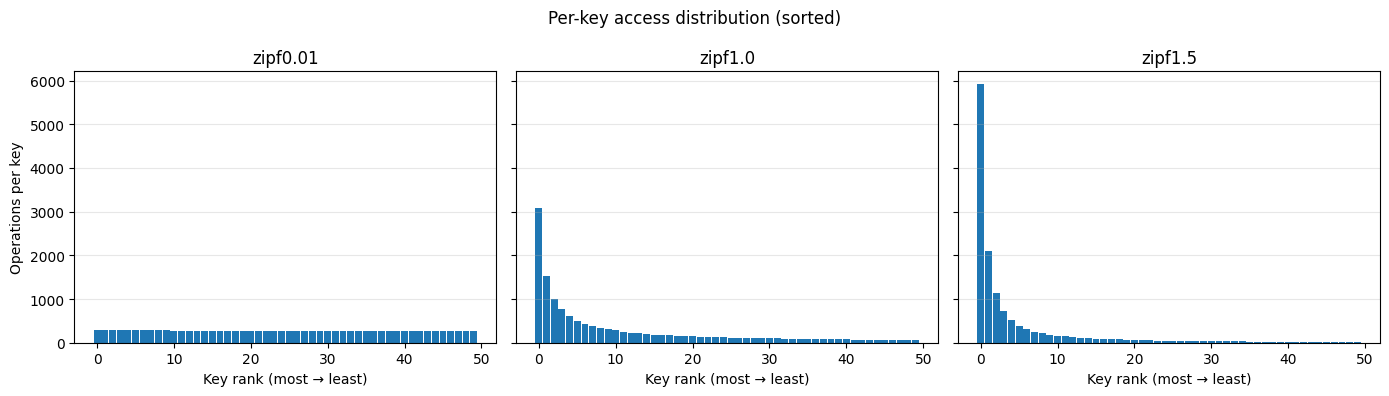

In [66]:
import numpy as np
import matplotlib.pyplot as plt

ZIPF_LEVELS = [0.01, 1.0, 1.5]

def plot_zipf_histograms(
    hist_data: dict,
    zipf_levels,
    bins=12,           # reduce number of bars
    keep_mass=1.0,     # set <1.0 if you want to drop tiny tail
    log_scale=False    # turn on if zipf1.5 dominates too much
):
    # First compute global max for consistent y-axis
    max_val = 0

    processed = {}

    for s in zipf_levels:
        counts = np.asarray(hist_data[s], dtype=float)
        counts = np.where(np.isfinite(counts), counts, 0.0)

        counts_sorted = np.sort(counts)[::-1]

        if keep_mass < 1.0:
            total = counts_sorted.sum()
            if total > 0:
                csum = np.cumsum(counts_sorted) / total
                k = int(np.searchsorted(csum, keep_mass) + 1)
                counts_sorted = counts_sorted[:max(k, 1)]

        # bin to reduce clutter
        b = min(bins, len(counts_sorted))
        chunks = np.array_split(counts_sorted, b)
        vals = np.array([chunk.sum() for chunk in chunks], dtype=float)

        processed[s] = vals
        max_val = max(max_val, vals.max() if len(vals) else 0)

    # ---- Plot ----
    fig, axes = plt.subplots(1, len(zipf_levels), figsize=(14, 4), sharey=True)

    if len(zipf_levels) == 1:
        axes = [axes]

    for ax, s in zip(axes, zipf_levels):
        vals = processed[s]
        x = np.arange(len(vals))

        ax.bar(
            x, vals,
            width=0.9,
            color="tab:blue",
            edgecolor="none",
        )

        ax.set_title(f"zipf{s}")
        ax.set_xlabel("Key rank (most → least)")
        ax.grid(True, axis="y", alpha=0.3)

        if log_scale:
            ax.set_yscale("log")

        ax.set_ylim(0, max_val * 1.05)

    axes[0].set_ylabel("Operations per key")
    fig.suptitle("Per-key access distribution (sorted)")
    fig.tight_layout()
    plt.show()

plot_zipf_histograms(
    HIST_DATA,
    ZIPF_LEVELS,
    bins=50,           # reduce number of bars
    keep_mass=1.0,     # set <1.0 if you want to drop tiny tail
    log_scale=False    # turn on if zipf1.5 dominates too much
)

/tmp/ipykernel_7992/3672127820.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


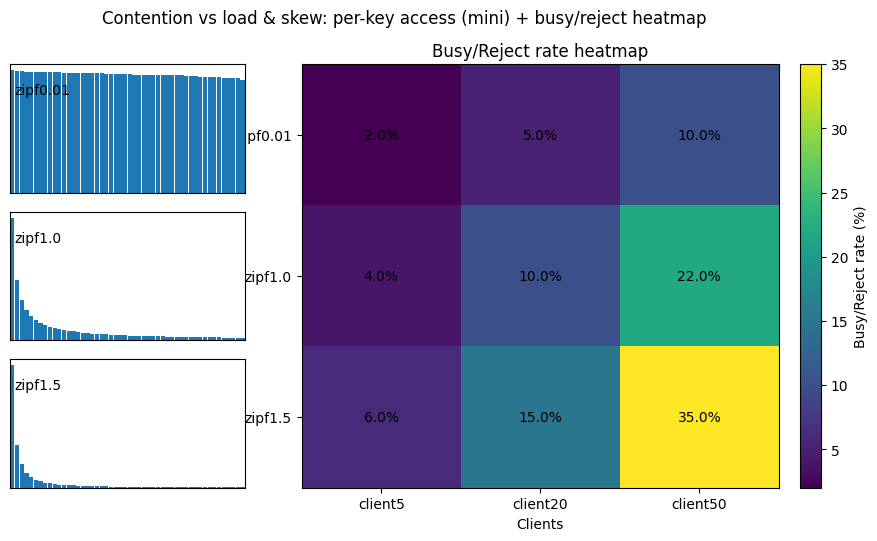

In [40]:
import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50]
ZIPF_LEVELS = [0.01, 1.0, 1.5]
PLOT_AS_PERCENT = True  # heatmap in %

def plot_heatmap_with_row_minihists(
    heat_data: dict,
    hist_data: dict,
    zipf_levels,
    client_levels,
    plot_as_percent=True,
    mini_width_ratio=0.55,   # smaller -> thinner mini-hists column
):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Build heatmap matrix (rows=zipf, cols=clients)
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)
    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    # Layout: thin left column for mini-hists, wide right for heatmap
    fig = plt.figure(figsize=(10.5, 5.5))
    gs = fig.add_gridspec(
        nrows=len(zipf_levels),
        ncols=2,
        width_ratios=[mini_width_ratio, 1.0],
        wspace=0.15,
        hspace=0.15,
    )

    # ---- Right: heatmap spanning all rows in a single axes (use a subgridspec trick)
    # We'll create it as one axes using gs[:, 1]
    axh = fig.add_subplot(gs[:, 1])
    im = axh.imshow(Z, aspect="auto")

    axh.set_xticks(np.arange(len(client_levels)), [f"client{c}" for c in client_levels])
    axh.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])
    axh.set_xlabel("Clients")
    axh.set_ylabel("Zipf skew (s)")
    axh.set_title("Busy/Reject rate heatmap")

    # annotate cells
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                axh.text(j, i, f"{v:.1f}{unit}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    cbar.set_label(f"Busy/Reject rate ({unit})" if unit else "Busy/Reject rate")

    # ---- Left: one mini-hist per row (vertical strip)
    for r, s in enumerate(zipf_levels):
        axm = fig.add_subplot(gs[r, 0])

        counts = np.asarray(hist_data[s], dtype=float)
        counts = np.where(np.isfinite(counts), counts, 0.0)

        # sorted access by key (desc)
        counts_sorted = np.sort(counts)[::-1]

        # "vertical manner": make it a tall thin bar sequence
        x = np.arange(len(counts_sorted))
        axm.bar(x, counts_sorted, width=0.9)

        # Clean tiny look
        axm.set_xlim(-0.5, len(counts_sorted) - 0.5)
        axm.set_xticks([])     # no x ticks
        axm.set_yticks([])     # no y ticks
        axm.grid(True, axis="y", alpha=0.2)

        # label each mini-hist row (aligned with heatmap row)
        axm.text(
            0.02, 0.85,
            f"zipf{s}",
            transform=axm.transAxes,
            ha="left", va="top"
        )
        
        # Optional: compress dynamic range if zipf1.5 dominates too hard
        # axm.set_yscale("log")

    fig.suptitle("Contention vs load & skew: per-key access (mini) + busy/reject heatmap")
    fig.tight_layout()
    plt.show()

plot_heatmap_with_row_minihists(
    HEAT_DATA,
    HIST_DATA,
    ZIPF_LEVELS,
    CLIENT_LEVELS,
    plot_as_percent=True,
    mini_width_ratio=0.45,  # thinner strips
)

/tmp/ipykernel_7992/2372372853.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


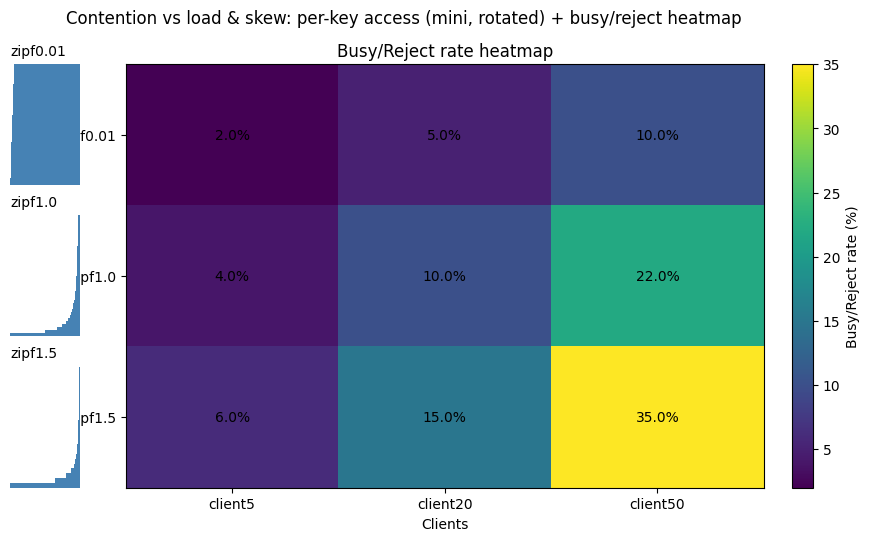

In [64]:
import numpy as np
import matplotlib.pyplot as plt

CLIENT_LEVELS = [5, 20, 50]
ZIPF_LEVELS = [0.01, 1.0, 1.5]
PLOT_AS_PERCENT = True

def plot_heatmap_with_rotated_minihists(
    heat_data: dict,
    hist_data: dict,
    zipf_levels,
    client_levels,
    plot_as_percent=True,
    mini_width_ratio=0.22,   # make mini-hists column smaller
    bins=12,                 # fewer bars (no need to show all keys)
    keep_mass=0.90,          # keep only the top keys that cover 90% of requests
):
    scale = 100.0 if plot_as_percent else 1.0
    unit = "%" if plot_as_percent else ""

    # Heatmap matrix
    Z = np.full((len(zipf_levels), len(client_levels)), np.nan, dtype=float)
    for i, s in enumerate(zipf_levels):
        for j, c in enumerate(client_levels):
            pt, lo, hi = heat_data[s][c]
            Z[i, j] = pt * scale

    fig = plt.figure(figsize=(10.5, 5.5))
    gs = fig.add_gridspec(
        nrows=len(zipf_levels),
        ncols=2,
        width_ratios=[mini_width_ratio, 1.0],
        wspace=0.12,
        hspace=0.25,
    )

    # --- Heatmap (right, spans all rows)
    axh = fig.add_subplot(gs[:, 1])
    im = axh.imshow(Z, aspect="auto")

    axh.set_xticks(np.arange(len(client_levels)), [f"client{c}" for c in client_levels])
    axh.set_yticks(np.arange(len(zipf_levels)), [f"zipf{s}" for s in zipf_levels])
    axh.set_xlabel("Clients")
    axh.set_ylabel("Zipf skew (s)")
    axh.set_title("Busy/Reject rate heatmap")

    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            v = Z[i, j]
            if np.isfinite(v):
                axh.text(j, i, f"{v:.1f}{unit}", ha="center", va="center")

    cbar = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    cbar.set_label(f"Busy/Reject rate ({unit})" if unit else "Busy/Reject rate")

    # --- Mini-hists (left: one per row), rotated 90° via barh
    for r, s in enumerate(zipf_levels):
        axm = fig.add_subplot(gs[r, 0])

        counts = np.asarray(hist_data[s], dtype=float)
        counts = np.where(np.isfinite(counts), counts, 0.0)

        # Sort descending (rank plot)
        counts_sorted = np.sort(counts)[::-1]

        # Drop tiny tail: keep keys that explain keep_mass of total requests
        total = counts_sorted.sum()
        if total > 0:
            csum = np.cumsum(counts_sorted) / total
            k = int(np.searchsorted(csum, keep_mass) + 1)
            counts_kept = counts_sorted[:max(k, 1)]
        else:
            counts_kept = counts_sorted

        # Bin into fewer bars to avoid clutter
        if len(counts_kept) > bins:
            n = len(counts_kept)
            b = min(bins, n)  # never more bins than items
            chunks = np.array_split(counts_kept, b)
            vals = np.array([chunk.sum() for chunk in chunks])
        else:
            vals = counts_kept

        # Normalize within row to [0,1] so strips are comparable in shape (optional but nice)
        vmax = vals.max() if vals.size else 1.0
        if vmax <= 0:
            vmax = 1.0
        vals_norm = vals / vmax

        # Rotated: horizontal bars (barh). This is visually a 90° rotation of the original.
        y = np.arange(len(vals_norm))
        axm.barh(y, vals_norm, height=1, color="steelblue", linewidth=0)

        # Compact strip styling
        axm.set_xlim(0, 1.0)
        axm.set_ylim(-0.5, len(vals_norm) - 0.5)
        axm.invert_yaxis()          # largest bin at top
        
        axm.set_xticks([])
        axm.set_yticks([])
        for spine in axm.spines.values():
            spine.set_visible(False)
        
        axm.invert_xaxis()
        axm.invert_yaxis()
        
        # Tiny label
        axm.text(0.0, 1.05, f"zipf{s}", transform=axm.transAxes, ha="left", va="bottom")

    fig.suptitle("Contention vs load & skew: per-key access (mini, rotated) + busy/reject heatmap")
    fig.tight_layout()
    plt.show()

plot_heatmap_with_rotated_minihists(
    HEAT_DATA,
    HIST_DATA,
    ZIPF_LEVELS,
    CLIENT_LEVELS,
    plot_as_percent=True,
    mini_width_ratio=0.10,  # even smaller
    bins=50,                # fewer bars
    keep_mass=0.95          # drop tiny tail
)